# BUILD AND DEPLOYMENT OF MACHINE LEARNING APPLICATIONS

# EXPERIMENT NO : 1

# Setting Up the Environment and Data Preprocessing

## AIM

To set up the machine learning development environment and preprocess the Students Performance dataset by exploring the data, handling missing values, encoding categorical variables, performing feature scaling, splitting the dataset into training and testing sets, and preparing the data for machine learning applications.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

print("="*60)
print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")
print("="*60)

ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY


In [4]:
df = pd.read_csv("StudentsPerformance.csv")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

DATASET LOADED SUCCESSFULLY


In [5]:
print("\n")
print("="*60)
print("DATASET PREVIEW")
print("="*60)

display(df.head(10))



DATASET PREVIEW


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [6]:
print("\n")
print("="*60)
print("DATASET SHAPE")
print("="*60)

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])



DATASET SHAPE
Number of Rows    : 1000
Number of Columns : 8


In [7]:
print("\n")
print("="*60)
print("COLUMN NAMES")
print("="*60)

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")



COLUMN NAMES
1. gender
2. race/ethnicity
3. parental level of education
4. lunch
5. test preparation course
6. math score
7. reading score
8. writing score


In [8]:
print("\n")
print("="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)



DATA TYPES
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [9]:
print("\n")
print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
print("\n")
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

display(df.describe())



SUMMARY STATISTICS


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())



MISSING VALUES
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total Missing Values : 0


In [12]:
print("\n")
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)

df.fillna(method='ffill', inplace=True)

print("Missing Values After Handling\n")
print(df.isnull().sum())



HANDLING MISSING VALUES
Missing Values After Handling

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [13]:
print("\n")
print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)



DUPLICATE RECORDS
Duplicate Records : 0


In [14]:
print("\n")
print("="*60)
print("DUPLICATE REMOVAL")
print("="*60)

rows_before = df.shape[0]

df.drop_duplicates(inplace=True)

rows_after = df.shape[0]

print("Rows Before :", rows_before)
print("Rows After  :", rows_after)
print("Duplicates Removed :", rows_before - rows_after)



DUPLICATE REMOVAL
Rows Before : 1000
Rows After  : 1000
Duplicates Removed : 0


In [15]:
print("\n")
print("="*60)
print("LABEL ENCODING")
print("="*60)

label_encoder = LabelEncoder()

label_columns = ['gender','lunch','test preparation course']

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])
    print(col,"Encoded Successfully")

display(df.head())



LABEL ENCODING
gender Encoded Successfully
lunch Encoded Successfully
test preparation course Encoded Successfully


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,1,1,72,72,74
1,0,group C,some college,1,0,69,90,88
2,0,group B,master's degree,1,1,90,95,93
3,1,group A,associate's degree,0,1,47,57,44
4,1,group C,some college,1,1,76,78,75


In [16]:
print("\n")
print("="*60)
print("ONE-HOT ENCODING")
print("="*60)

df = pd.get_dummies(df,
                    columns=['race/ethnicity',
                             'parental level of education'],
                    drop_first=True)

print("One-Hot Encoding Completed Successfully")

display(df.head())



ONE-HOT ENCODING
One-Hot Encoding Completed Successfully


,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,1,72,72,74,1,0,0,0,1,0,0,0,0
1,0,1,0,69,90,88,0,1,0,0,0,0,0,1,0
2,0,1,1,90,95,93,1,0,0,0,0,0,1,0,0
3,1,0,1,47,57,44,0,0,0,0,0,0,0,0,0
4,1,1,1,76,78,75,0,1,0,0,0,0,0,1,0


In [17]:
print("\n")
print("="*60)
print("STANDARDIZATION")
print("="*60)

standard_scaler = StandardScaler()

standard_columns = ['math score',
                    'reading score',
                    'writing score']

df_standard = df.copy()

df_standard[standard_columns] = standard_scaler.fit_transform(df_standard[standard_columns])

display(df_standard.head())



STANDARDIZATION


,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,1,0.390024,0.193999,0.391492,1,0,0,0,1,0,0,0,0
1,0,1,0,0.192076,1.427476,1.313269,0,1,0,0,0,0,0,1,0
2,0,1,1,1.577711,1.770109,1.642475,1,0,0,0,0,0,1,0,0
3,1,0,1,-1.259543,-0.833899,-1.583744,0,0,0,0,0,0,0,0,0
4,1,1,1,0.653954,0.605158,0.457333,0,1,0,0,0,0,0,1,0


In [18]:
print("\n")
print("="*60)
print("NORMALIZATION")
print("="*60)

minmax_scaler = MinMaxScaler()

df_normalized = df_standard.copy()

df_normalized[standard_columns] = minmax_scaler.fit_transform(df_normalized[standard_columns])

display(df_normalized.head())



NORMALIZATION


,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,1,0.72,0.662651,0.711111,1,0,0,0,1,0,0,0,0
1,0,1,0,0.69,0.879518,0.866667,0,1,0,0,0,0,0,1,0
2,0,1,1,0.90,0.939759,0.922222,1,0,0,0,0,0,1,0,0
3,1,0,1,0.47,0.481928,0.377778,0,0,0,0,0,0,0,0,0
4,1,1,1,0.76,0.734940,0.722222,0,1,0,0,0,0,0,1,0




BOX PLOT


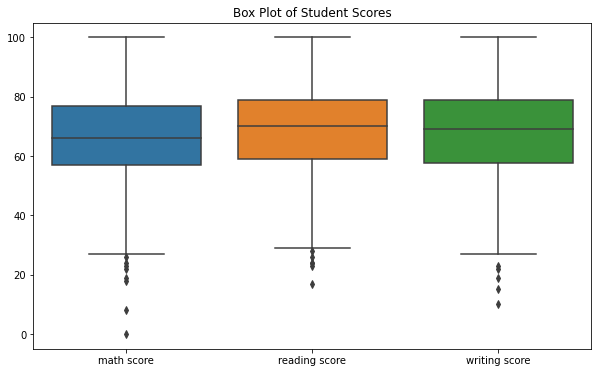

In [19]:
print("\n")
print("="*60)
print("BOX PLOT")
print("="*60)

plt.figure(figsize=(10,6))

sns.boxplot(data=df[['math score',
                     'reading score',
                     'writing score']])

plt.title("Box Plot of Student Scores")

plt.show()

In [20]:
print("\n")
print("="*60)
print("TRAIN-TEST DATA SPLITTING")
print("="*60)

X = df_normalized.drop(columns=['math score'])

y = df_normalized['math score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)



TRAIN-TEST DATA SPLITTING
Training Features Shape : (800, 14)
Testing Features Shape  : (200, 14)
Training Target Shape   : (800,)
Testing Target Shape    : (200,)


In [21]:
print("\n")
print("="*60)
print("FINAL PREPROCESSED DATASET")
print("="*60)

display(df_normalized.head(10))



FINAL PREPROCESSED DATASET


,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,1,0.72,0.662651,0.711111,1,0,0,0,1,0,0,0,0
1,0,1,0,0.69,0.879518,0.866667,0,1,0,0,0,0,0,1,0
2,0,1,1,0.90,0.939759,0.922222,1,0,0,0,0,0,1,0,0
3,1,0,1,0.47,0.481928,0.377778,0,0,0,0,0,0,0,0,0
4,1,1,1,0.76,0.734940,0.722222,0,1,0,0,0,0,0,1,0
5,0,1,1,0.71,0.795181,0.755556,1,0,0,0,0,0,0,0,0
6,0,1,0,0.88,0.939759,0.911111,1,0,0,0,0,0,0,1,0
7,1,0,1,0.40,0.313253,0.322222,1,0,0,0,0,0,0,1,0
8,1,0,0,0.64,0.566265,0.633333,0,0,1,0,0,1,0,0,0
9,0,0,1,0.38,0.518072,0.444444,1,0,0,0,0,1,0,0,0


In [22]:
print("\n")
print("="*60)
print("FINAL DATASET SHAPE")
print("="*60)

print("Rows    :", df_normalized.shape[0])
print("Columns :", df_normalized.shape[1])

print("\n")

print("="*60)
print("DATA TYPES AFTER PREPROCESSING")
print("="*60)

print(df_normalized.dtypes)



FINAL DATASET SHAPE
Rows    : 1000
Columns : 15


DATA TYPES AFTER PREPROCESSING
gender                                             int32
lunch                                              int32
test preparation course                            int32
math score                                       float64
reading score                                    float64
writing score                                    float64
race/ethnicity_group B                             uint8
race/ethnicity_group C                             uint8
race/ethnicity_group D                             uint8
race/ethnicity_group E                             uint8
parental level of education_bachelor's degree      uint8
parental level of education_high school            uint8
parental level of education_master's degree        uint8
parental level of education_some college           uint8
parental level of education_some high school       uint8
dtype: object


In [23]:

print("\n")
print("="*60)
print("FINAL VERIFICATION")
print("="*60)

print("Missing Values Remaining :", df_normalized.isnull().sum().sum())
print("Duplicate Records        :", df_normalized.duplicated().sum())

print("\n")

print("Dataset is Ready for Machine Learning.")



FINAL VERIFICATION
Missing Values Remaining : 0
Duplicate Records        : 0


Dataset is Ready for Machine Learning.


## RESULT

The Students Performance dataset was successfully preprocessed by exploring the dataset, checking and handling missing values and duplicate records, encoding categorical variables using Label Encoding and One-Hot Encoding, performing Standardization and Normalization, and splitting the dataset into training and testing sets. The final preprocessed dataset is now ready for further machine learning applications.